# 01 – Problem Setup
**Project**: Playlist Optimizer  
**Author**: S33mi  

Goal: Formulate playlist creation as an optimization problem and prepare the data/structures we will optimize later (GA, SA, etc.).

This notebook:
1. Loads artifacts from the [`Spotify music recommender`](https://github.com/S33mi/spotify-music-recommender) project
2. Defines the decision variables, objectives, and constraints
3. Implements a playlist scoring function
4. Creates simple baseline playlists for comparison

## 1. Setup & Imports

In [ ]:
import os
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
import requests #url based method

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_colwidth", 80)

print("Libraries loaded.")

Libraries loaded.


## 2. Load Data from Spotify Recommender Project

Expected artifacts (adjust paths if needed):
- `spotify_with_clusters.csv` (or the two part files)
- `X_scaled.npy`
- optional: `mood_labels.pkl`


In [ ]:
# -------------------------------------------------
# Config – GitHub raw URLs (same as the official demo)
# -------------------------------------------------
BASE_URL = "https://raw.githubusercontent.com/S33mi/spotify-music-recommender/main"

URL_PART1 = f"{BASE_URL}/data/processed/spotify_with_clusters_part1.csv"
URL_PART2 = f"{BASE_URL}/data/processed/spotify_with_clusters_part2.csv"
URL_X     = f"{BASE_URL}/data/processed/X_scaled.npy"
URL_MOOD  = f"{BASE_URL}/data/models/mood_labels.pkl"

# Optional local fallbacks (if you have the files)
LOCAL_CSV   = "data/processed/spotify_with_clusters.csv"
LOCAL_PART1 = "data/processed/spotify_with_clusters_part1.csv"
LOCAL_PART2 = "data/processed/spotify_with_clusters_part2.csv"
LOCAL_X     = "data/processed/X_scaled.npy"
LOCAL_MOOD  = "data/models/mood_labels.pkl"

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def _download(url: str) -> bytes:
    print(f"Downloading {url} ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return r.content

def load_dataframe() -> pd.DataFrame:
    # 1. Prefer a single local merged CSV
    if os.path.exists(LOCAL_CSV):
        print(f"Loading local CSV: {LOCAL_CSV}")
        return pd.read_csv(LOCAL_CSV)

    # 2. Prefer local split parts
    if os.path.exists(LOCAL_PART1) and os.path.exists(LOCAL_PART2):
        print("Merging local part1 + part2 ...")
        return pd.concat(
            [pd.read_csv(LOCAL_PART1), pd.read_csv(LOCAL_PART2)],
            ignore_index=True
        )

    # 3. Fallback: download the two parts from GitHub
    print("Local files not found – downloading from GitHub ...")
    p1 = _download(URL_PART1)
    p2 = _download(URL_PART2)

    df1 = pd.read_csv(BytesIO(p1))
    df2 = pd.read_csv(BytesIO(p2))
    return pd.concat([df1, df2], ignore_index=True)

def load_npy(path: str, url: str) -> np.ndarray:
    if os.path.exists(path):
        print(f"Loading local: {path}")
        return np.load(path)
    print(f"Local {path} not found – downloading ...")
    return np.load(BytesIO(_download(url)))

def load_pkl(path: str, url: str):
    if os.path.exists(path):
        print(f"Loading local: {path}")
        return joblib.load(path)
    print(f"Local {path} not found – downloading ...")
    return joblib.load(BytesIO(_download(url)))

# -------------------------------------------------
# Load everything
# -------------------------------------------------
df = load_dataframe()
X = load_npy(LOCAL_X, URL_X)

mood_labels = load_pkl(LOCAL_MOOD, URL_MOOD)
if "mood" not in df.columns and "cluster" in df.columns:
    df["mood"] = df["cluster"].map(mood_labels)

print(f"Tracks loaded : {len(df)}")
print(f"Feature matrix: {X.shape}")
df.head(3)

Local files not found – downloading from GitHub ...
Local data/processed/X_scaled.npy not found – downloading ...
Local data/models/mood_labels.pkl not found – downloading ...
Tracks loaded : 89741
Feature matrix: (89741, 10)


,track_id,track_name,artists,album_name,track_genre,popularity,danceability,energy,loudness,speechiness,...,valence,tempo,duration_min,cluster,mood,.2262683996597979,0.0533142194659752,-0.0292332590579332,2,Dark / Intense
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73.0,0.644260,-0.675976,0.335731,0.490464,...,0.934036,-1.133609,0.013495,1.0,Acoustic / Chill,NaN,NaN,NaN,NaN,NaN
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55.0,-0.804604,-1.825609,-1.673094,-0.098361,...,-0.770280,-1.479854,-0.704151,3.0,Happy Pop,NaN,NaN,NaN,NaN,NaN
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57.0,-0.702731,-1.073476,-0.236523,-0.280217,...,-1.329508,-1.518271,-0.162163,3.0,Happy Pop,NaN,NaN,NaN,NaN,NaN


### Keep only useful columns + features

In [ ]:
meta_cols = ["track_id", "track_name", "artists", "track_genre", "popularity"]
if "mood" in df.columns:
    meta_cols.append("mood")
if "cluster" in df.columns:
    meta_cols.append("cluster")

# Original (unscaled) audio features if present – useful for interpretation
raw_audio_cols = [
    c for c in [
        "danceability", "energy", "loudness", "speechiness",
        "acousticness", "instrumentalness", "liveness",
        "valence", "tempo", "duration_min", "duration_ms"
    ] if c in df.columns
]

# We work with the scaled matrix X for similarity / distances
assert len(df) == len(X), "df and X length mismatch – check preprocessing"

## 3. Problem Formulation

### Decision variables
An ordered sequence of track indices:  
\( p = (t_1, t_2, \dots, t_L) \)  
where \( L \) is the desired playlist length.

### Objectives (to balance)
1. **Flow / smoothness** – small changes in energy & tempo between consecutive tracks  
2. **Seed similarity** – tracks should stay reasonably close to the seed (or seed set)  
3. **Diversity** – avoid near-duplicate tracks  
4. **Mood consistency** (optional) – prefer tracks from the same mood cluster

### Constraints
- Fixed length \( L \)
- No duplicate tracks
- Optional: duration range, popularity floor, genre limits

## 4. Core Scoring Functions

In [ ]:
def playlist_energy_tempo(df, indices, energy_col="energy", tempo_col="tempo"):
    """Return energy and tempo arrays for a list of positional indices."""
    # Prefer raw columns if available; otherwise we cannot plot absolute values
    if energy_col in df.columns and tempo_col in df.columns:
        energy = df.iloc[indices][energy_col].values
        tempo = df.iloc[indices][tempo_col].values
    else:
        energy = np.zeros(len(indices))
        tempo = np.zeros(len(indices))
    return energy, tempo

def smoothness_score(energy, tempo, energy_weight=0.6, tempo_weight=0.4):
    """
    Higher is better.
    Penalizes large consecutive jumps in energy and tempo.
    """
    if len(energy) < 2:
        return 1.0
    energy_jumps = np.abs(np.diff(energy))
    tempo_jumps = np.abs(np.diff(tempo)) / 50.0   # rough normalization
    penalty = energy_weight * energy_jumps.mean() + tempo_weight * tempo_jumps.mean()
    return 1.0 / (1.0 + penalty)

def seed_similarity_score(X, seed_idx, playlist_indices):
    """Average cosine similarity of playlist tracks to the seed."""
    seed_vec = X[seed_idx].reshape(1, -1)
    playlist_vecs = X[playlist_indices]
    sims = cosine_similarity(seed_vec, playlist_vecs)[0]
    return float(sims.mean())

def diversity_score(X, playlist_indices):
    """
    Higher is better.
    1 - average pairwise cosine similarity inside the playlist.
    """
    if len(playlist_indices) < 2:
        return 1.0
    vecs = X[playlist_indices]
    sim_matrix = cosine_similarity(vecs)
    # upper triangle without diagonal
    n = len(playlist_indices)
    triu = sim_matrix[np.triu_indices(n, k=1)]
    return float(1.0 - triu.mean())

def mood_consistency_score(df, playlist_indices, seed_idx):
    """Fraction of tracks that share the seed's mood (if available)."""
    if "mood" not in df.columns:
        return 0.5  # neutral
    seed_mood = df.iloc[seed_idx]["mood"]
    moods = df.iloc[playlist_indices]["mood"]
    return float((moods == seed_mood).mean())

def total_playlist_score(
    df,
    X,
    seed_idx,
    playlist_indices,
    w_smooth=0.30,
    w_sim=0.30,
    w_div=0.25,
    w_mood=0.15,
):
    """
    Scalar objective to maximize.
    All component scores are roughly in [0, 1].
    """
    energy, tempo = playlist_energy_tempo(df, playlist_indices)
    s_smooth = smoothness_score(energy, tempo)
    s_sim = seed_similarity_score(X, seed_idx, playlist_indices)
    s_div = diversity_score(X, playlist_indices)
    s_mood = mood_consistency_score(df, playlist_indices, seed_idx)

    score = (
        w_smooth * s_smooth
        + w_sim * s_sim
        + w_div * s_div
        + w_mood * s_mood
    )
    components = {
        "smoothness": s_smooth,
        "seed_similarity": s_sim,
        "diversity": s_div,
        "mood_consistency": s_mood,
        "total": score,
    }
    return score, components

## 5. Helper: Build & Evaluate a Playlist

In [ ]:
def show_playlist(df, indices, title="Playlist"):
    cols = ["track_name", "artists", "track_genre", "popularity"]
    if "mood" in df.columns:
        cols.append("mood")
    if "energy" in df.columns:
        cols.append("energy")
    if "tempo" in df.columns:
        cols.append("tempo")
    out = df.iloc[indices][cols].copy()
    out.index = range(1, len(out) + 1)
    print(title)
    display(out)
    return out

def plot_energy_tempo(df, indices, title="Energy & Tempo progression"):
    energy, tempo = playlist_energy_tempo(df, indices)
    fig, ax1 = plt.subplots(figsize=(11, 4))
    x = np.arange(1, len(indices) + 1)
    ax1.plot(x, energy, "o-", color="steelblue", label="Energy")
    ax1.set_ylabel("Energy", color="steelblue")
    ax1.set_xlabel("Track position")
    ax2 = ax1.twinx()
    ax2.plot(x, tempo, "s--", color="darkorange", label="Tempo")
    ax2.set_ylabel("Tempo (BPM)", color="darkorange")
    plt.title(title)
    fig.tight_layout()
    plt.show()

## 6. Baselines

We create two simple baselines for later comparison with GA / SA:
1. **Random** playlist (same length, no duplicates)
2. **Nearest-Neighbor** playlist (greedy similarity to seed)

In [ ]:
def random_playlist(n_tracks, length, seed_idx=None, random_state=42):
    rng = np.random.default_rng(random_state)
    candidates = np.arange(n_tracks)
    if seed_idx is not None:
        candidates = np.delete(candidates, seed_idx)
    chosen = rng.choice(candidates, size=length, replace=False)
    return chosen.tolist()

def nn_playlist(X, seed_idx, length):
    """Greedy: pick the `length` most similar tracks to the seed (excluding itself)."""
    seed_vec = X[seed_idx].reshape(1, -1)
    sims = cosine_similarity(seed_vec, X)[0]
    sims[seed_idx] = -np.inf
    top = np.argsort(sims)[-length:][::-1]
    return top.tolist()

### Pick a seed track and generate baselines

In [ ]:
# Change this query to any track you like
SEED_QUERY = "blinding lights"

mask = df["track_name"].str.lower().str.contains(SEED_QUERY.lower(), na=False)
if mask.sum() == 0:
    # fallback: first track
    seed_idx = 0
    print("Query not found – using first track as seed.")
else:
    seed_idx = mask.idxmax()   # first match
    # convert label index to positional index for X
    seed_idx = df.index.get_loc(seed_idx)

seed_row = df.iloc[seed_idx]
print("Seed track:")
print(f"  {seed_row['track_name']} — {seed_row['artists']}")
print(f"  Genre: {seed_row.get('track_genre', 'N/A')} | Mood: {seed_row.get('mood', 'N/A')}")

PLAYLIST_LENGTH = 12

Seed track:
  Blinding Lights — Kidz Bop Kids
  Genre: children | Mood: Acoustic / Chill



=== Random Baseline ===
Random playlist


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Remedy,Seether,grunge,70.0,Upbeat Electronic,1.237481,0.190776
2,Hands Up,City Wolf,blues,53.0,Upbeat Electronic,0.952996,1.256308
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Parisienne Walkways,Gary Moore;Phil Lynott,blues,55.0,Happy Pop,-1.525536,1.739617
8,Desilusão,Cleverson Silva;Marsena,groove,24.0,Acoustic / Chill,0.691893,-0.864495
9,Pula,Tihuana,brazil,49.0,Acoustic / Chill,1.179025,0.501295
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Scores: {'smoothness': np.float64(nan), 'seed_similarity': 0.359, 'diversity': 0.871, 'mood_consistency': 0.167, 'total': np.float64(nan)}


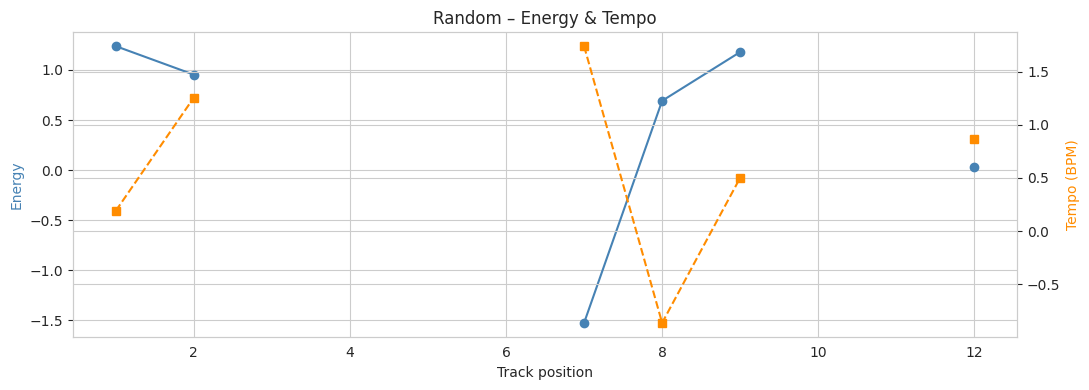

In [ ]:
# Baseline 1 – Random
rand_idx = random_playlist(len(df), PLAYLIST_LENGTH, seed_idx=seed_idx, random_state=42)
rand_score, rand_comp = total_playlist_score(df, X, seed_idx, rand_idx)

print("\n=== Random Baseline ===")
show_playlist(df, rand_idx, "Random playlist")
print("Scores:", {k: round(v, 3) for k, v in rand_comp.items()})
plot_energy_tempo(df, rand_idx, "Random – Energy & Tempo")



=== Nearest-Neighbor Baseline ===
NN playlist


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Atrakce,PAWLIE POIZN;Medooza,emo,36.0,Acoustic / Chill,0.391819,1.588907
2,My Person,Spencer Crandall,country,61.0,Acoustic / Chill,0.461966,1.457886
3,Mob Rule,Bad//Dreems,garage,29.0,Acoustic / Chill,0.621745,1.490093
4,My Person,Spencer Crandall,country,55.0,Acoustic / Chill,0.477554,1.459347
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1+1,Ready Kirken,folk,46.0,Acoustic / Chill,0.306083,1.757979
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Manohari,Divya Kumar;Neeti Mohan,folk,55.0,Acoustic / Chill,0.645128,1.259728
10,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215


Scores: {'smoothness': np.float64(nan), 'seed_similarity': 0.982, 'diversity': 0.032, 'mood_consistency': 0.75, 'total': np.float64(nan)}


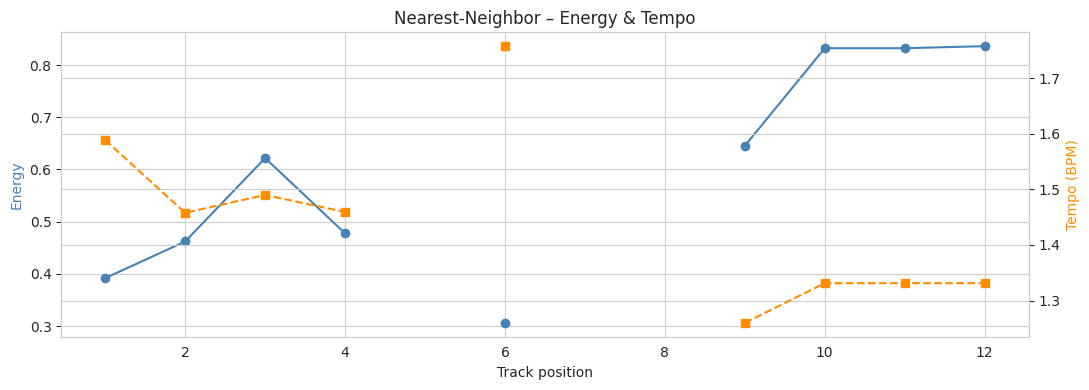

In [ ]:
# Baseline 2 – Nearest Neighbor
nn_idx = nn_playlist(X, seed_idx, PLAYLIST_LENGTH)
nn_score, nn_comp = total_playlist_score(df, X, seed_idx, nn_idx)

print("\n=== Nearest-Neighbor Baseline ===")
show_playlist(df, nn_idx, "NN playlist")
print("Scores:", {k: round(v, 3) for k, v in nn_comp.items()})
plot_energy_tempo(df, nn_idx, "Nearest-Neighbor – Energy & Tempo")

## 7. Save Setup Artifacts (optional)

In [ ]:
os.makedirs("data", exist_ok=True)

# Save a small config so later notebooks stay consistent
setup = {
    "seed_idx": int(seed_idx),
    "seed_track_id": str(seed_row["track_id"]),
    "playlist_length": PLAYLIST_LENGTH,
    "weights": {"smooth": 0.30, "sim": 0.30, "div": 0.25, "mood": 0.15},
}
joblib.dump(setup, "data/setup_config.pkl")
print("Saved data/setup_config.pkl")

Saved data/setup_config.pkl


## 8. Summary of the Optimization Problem

| Element | Definition |
|---------|------------|
| **Solution** | Ordered list of `PLAYLIST_LENGTH` unique track indices |
| **Objective** | Maximize `total_playlist_score` (weighted sum of smoothness, seed similarity, diversity, mood) |
| **Constraints** | No duplicates, fixed length (duration / popularity filters can be added later) |
| **Baselines** | Random, Nearest-Neighbor |

Next notebooks will search the space of playlists with:
- Genetic Algorithm (`03_genetic_algorithm.ipynb`)
- Simulated Annealing (`04_simulated_annealing.ipynb`)

and compare them against the similar baselines above.